In [1]:
import pandas as pd
import torch.nn.functional as F
import transformers
import argparse
import matplotlib.pyplot as plt
from DataLoad_simple import RNA_Seq_eval,RNA_Seq_analysis
from model_cmm import miRNAModel,mRNA_encoder,contrastive_mRNA
import os
import random
import tqdm
import numpy as np
import torch
import torch.nn as nn
from torch.utils import data
from transformers import DebertaTokenizerFast, T5EncoderModel, T5Config
import json
import torch.nn.functional as F
from sklearn.metrics import recall_score,f1_score, precision_score, roc_auc_score,confusion_matrix,auc,roc_curve


In [2]:
with open('data/miran2name.json', 'r') as f:
    miran2name = json.load(f)

In [2]:
if __name__ == '__main__':
    # Set CUDA device
    #python trainer.py --data_path "data1" --model_name "model_d2v_mfe0_ss0_specific.pt" --load_model True --cuda_device "3"
    #os.environ['OMP_NUM_THREADS'] = '1'
    os.environ['CUDA_VISIBLE_DEVICES'] = '0'
    #torch.cuda.set_device(int(args.cuda_device))
    data_path = 'cds_large'
    DATA_PATH = f'./data/{data_path}.json'
    TOKENIZER_PATH = "./tokenizer_3mers/"
    TOKENIZER_PATH_1mer = "./tokenizer_3mers/"

    MODEL_PATH = './checkpoint/model_mm_3mer_130klong_4_wo_kl.pt'
    criterion_cross = nn.CrossEntropyLoss()
    BATCH_SIZE = 64
    EPOCHS = 1
    encoder_mi = miRNAModel(num_attention_heads=2, num_hidden_layers=4, pad_token_id=3, hidden_size=128).cuda()
    encoder_m = mRNA_encoder(num_attention_heads=2, num_hidden_layers=4, pad_token_id=3, hidden_size=128).cuda()
    ckpt = torch.load(MODEL_PATH, map_location='cpu')
    model = contrastive_mRNA(encoder_mi,encoder_m)
    model.load_state_dict(ckpt['state_dict'], strict=True)
    #print(ckpt['ema']['encoder.encoder.block.0.layer.0.SelfAttention.q.weight'])
    #print('+++++++++++++++++++++++')
    #print(ckpt['m_encoder']['encoder.encoder.block.0.layer.0.SelfAttention.q.weight'])

    #print(hhh)
    
    #model.encoder_mRNA.load_state_dict(ckpt['ema'], strict=True)
    
    
    model = model.cuda()
    valid_db = RNA_Seq_eval(data_path='./data/ENST00000487099@UGAGGUAGUAGGUUGUGUGGUU_test_vis2.json', tokenizer_path=TOKENIZER_PATH,tokenizer_1mer = TOKENIZER_PATH_1mer, max_length=700)
    #valid_db = RNA_Seq_eval(data_path='./data/CDS_test_name.json', tokenizer_path=TOKENIZER_PATH,tokenizer_1mer = TOKENIZER_PATH_1mer, max_length=1024)
    val_loader = torch.utils.data.DataLoader(valid_db, batch_size=BATCH_SIZE, num_workers=1)

  
    model.eval()

    all_probabilities = []
    all_label = []
    all_label_pred = []
    kk=0
    all_prob = []
    mirna_name_list = []
    for no, batch_test in enumerate(val_loader):
        kk=kk+1
        miRNA,miRNA_attention, mRNA, mRNA_attention,starts_one,ends_one,labels_test = [x.cuda() for x in batch_test[:-3]]
        target_seq = batch_test[-3]
        dna_raw = batch_test[-2]
        mirna_raw = batch_test[-1]
        #miRNA,miRNA_attention,target_site, target_site_attention, mRNA,mRNA_attention,labels_test = [x.cuda() for x in batch_test]

        #print(miRNA)
        with torch.no_grad():
            #ll= model(miRNA,miRNA_attention,target_site, target_site_attention,mRNA,mRNA_attention)
            #print(len(ll))
            labels_test = (labels_test).view(-1,1).float()
            #print(labels_test.view(-1))
            attention_weight,clf_result_long = model.forward_eval(miRNA,miRNA_attention,mRNA, mRNA_attention)
            probabilities = torch.sigmoid(clf_result_long)

                    
            #all_prob.extend(probabilities.squeeze().cpu().numpy())
            predicted_labels = (probabilities >= 0.5).float()  # Convert to 0 or 1
            #print(probabilities.view(-1))
            correct_predictions = (predicted_labels == labels_test).float()  # 1 if correct, 0 if incorrect
            accuracy = correct_predictions.mean()
            print(accuracy)
            all_probabilities.extend(list(probabilities.view(-1).cpu().numpy()))
            all_label.extend(list(labels_test.view(-1).cpu().numpy()))
            all_label_pred.extend(list(predicted_labels.view(-1).cpu().numpy()))
            if kk>9:
                break
                
                

#attention_weight
            

3
tensor(1., device='cuda:0')


In [7]:
torch.save(attention_weight, './reuslt/attention_weight_ENST00000487099@UGAGGUAGUAGGUUGUGUGGUU.pt')
attention_weight = torch.load('./reuslt/attention_weight_ENST00000487099@UGAGGUAGUAGGUUGUGUGGUU.pt')

# Check its shape or values
print(attention_weight.shape)



torch.Size([3, 14, 700])


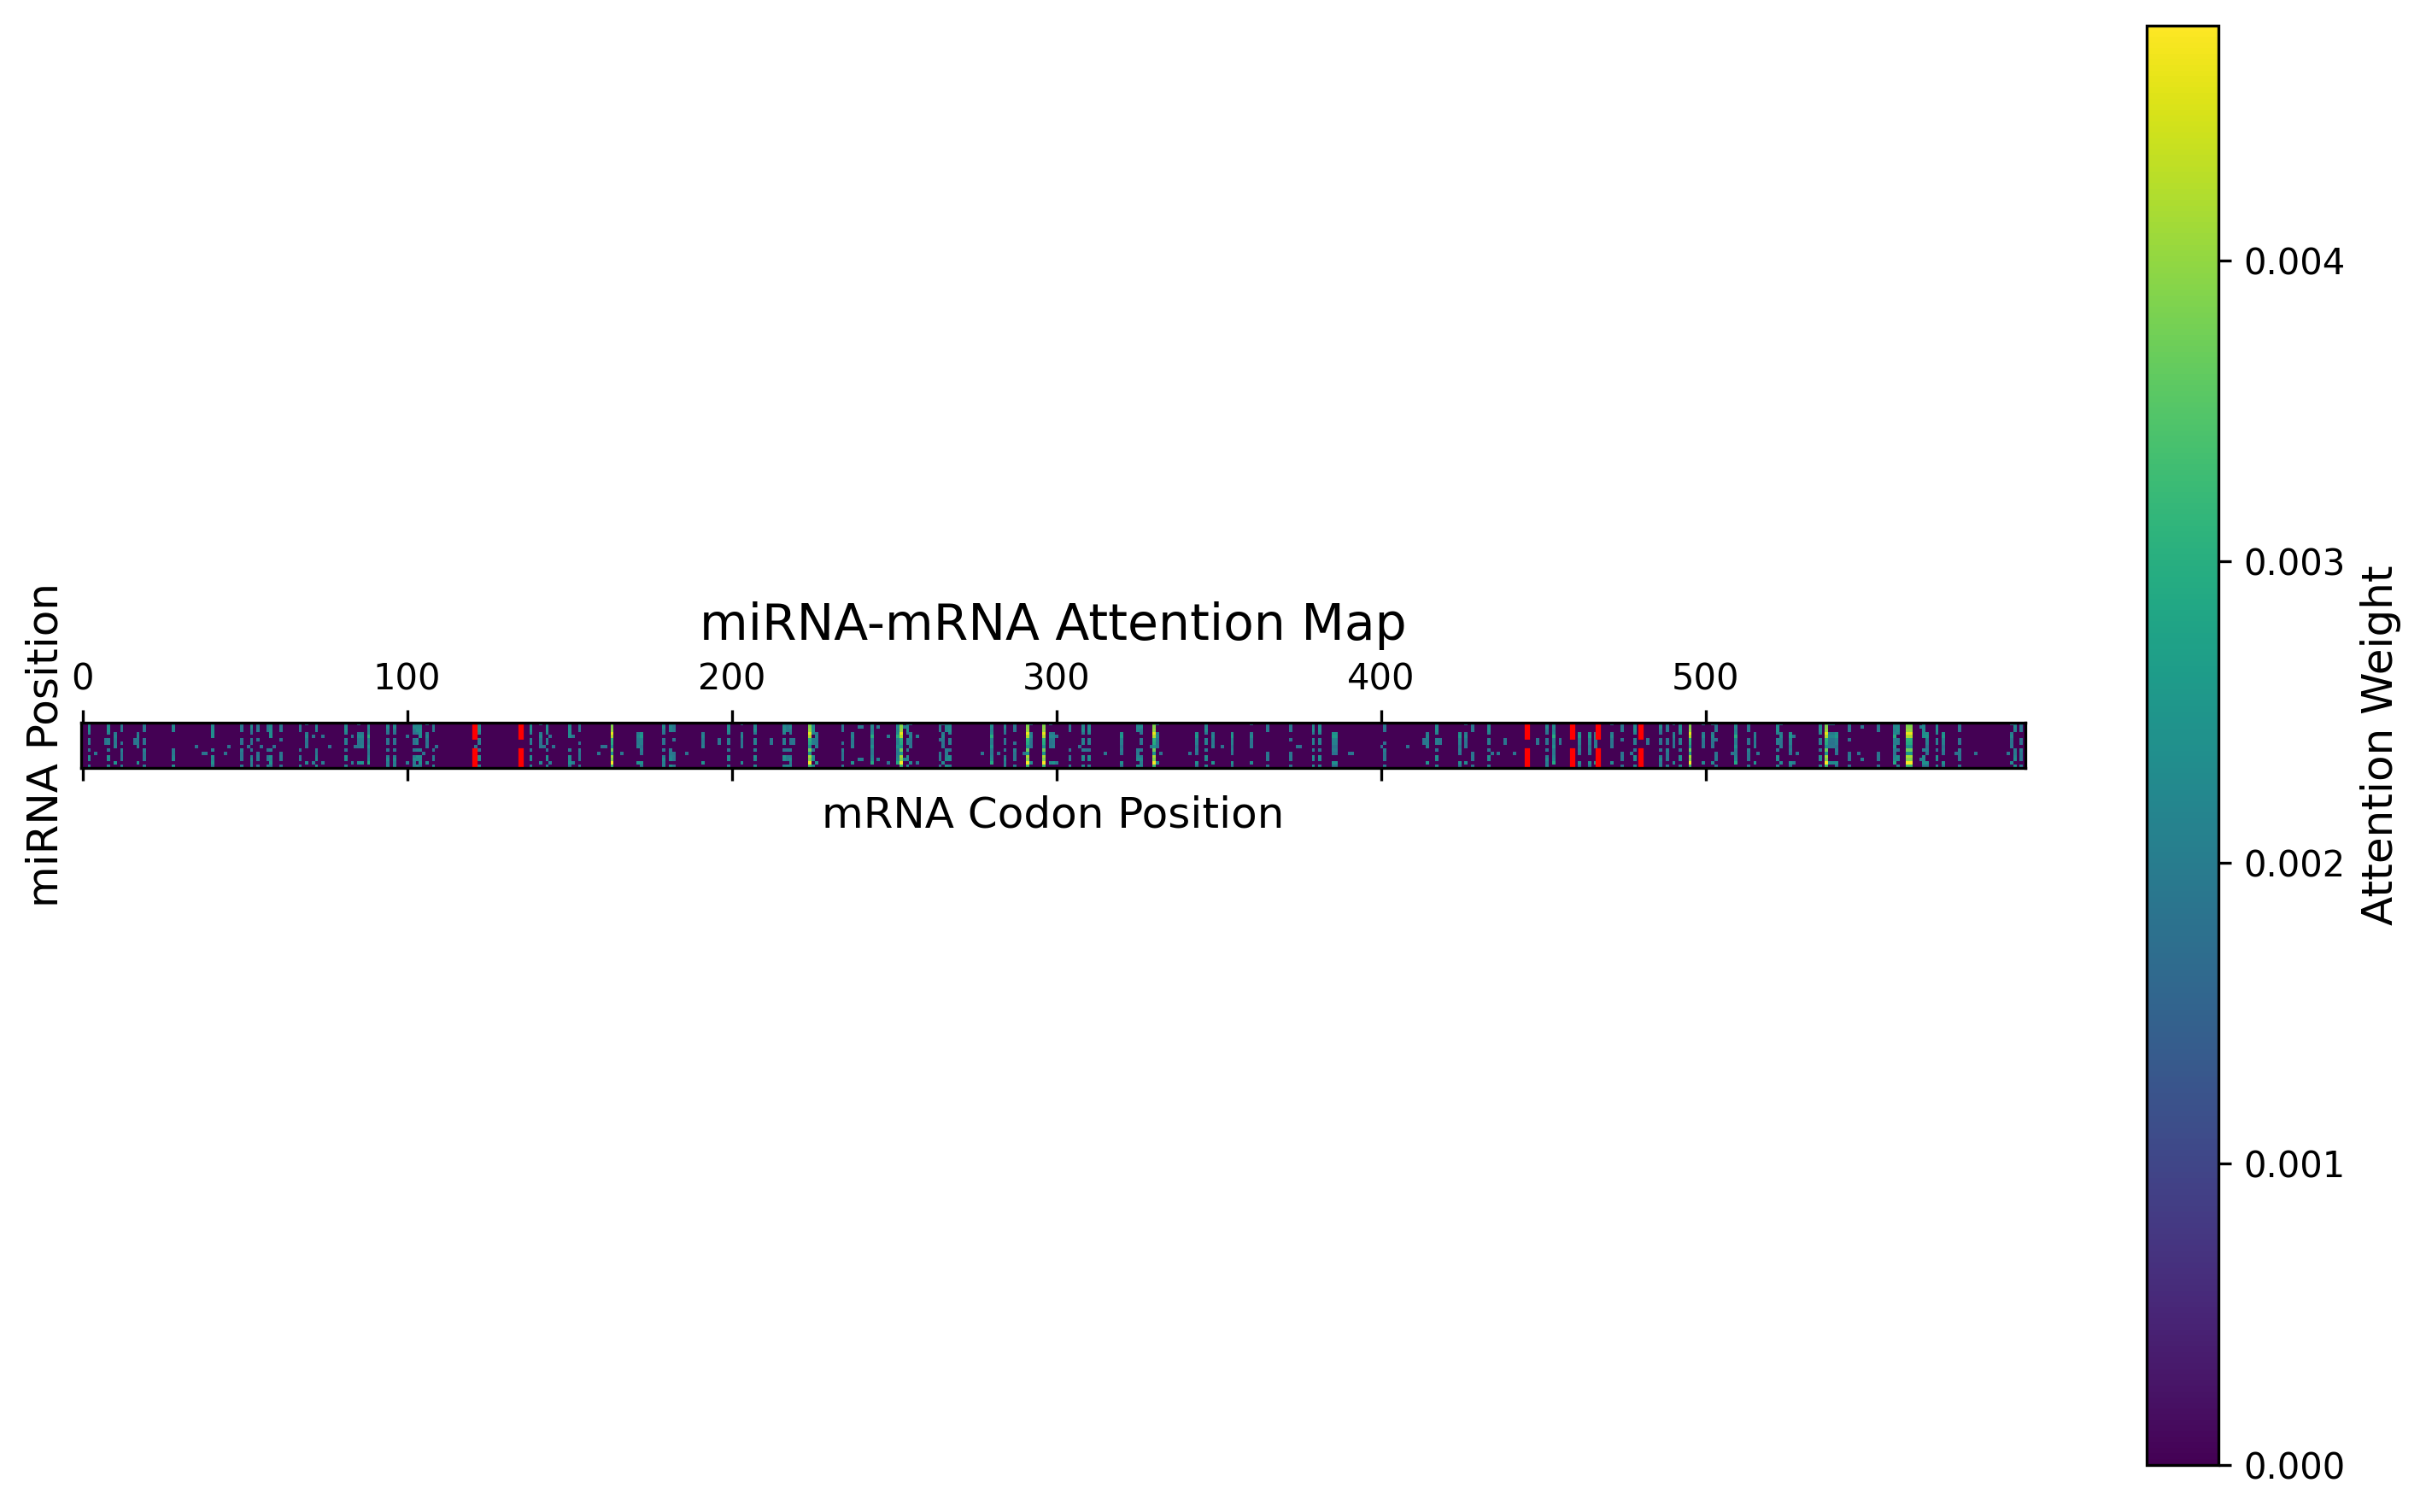

In [32]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Mask low attention weights
attention_weight[attention_weight < 0.0018] = 0.0

num_row = 0
attn_data = attention_weight[num_row, :, 1:600].cpu().numpy()

# Plot attention heatmap
im = ax.matshow(attn_data, cmap='viridis')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Attention Weight', fontsize=12)

# Label axes
ax.set_xlabel('mRNA Codon Position', fontsize=12)
ax.set_ylabel('miRNA Position', fontsize=12)
ax.set_yticks([])
# Optional: Customize tick labels (if sequence info is available)
# ax.set_yticks(np.arange(len(target_seq)))
# ax.set_yticklabels(list(target_seq))

# Add vertical lines for binding site regions
for i in range(3):
    start = int(starts_one[num_row + i].cpu().numpy() / 3) + 2
    end = int(ends_one[num_row + i].cpu().numpy() / 3) + 2
    ax.axvline(x=start, color='red', linestyle='--', linewidth=1.5)
    ax.axvline(x=end, color='red', linestyle='--', linewidth=1.5)

# Optional: Add title
ax.set_title('miRNA-mRNA Attention Map', fontsize=14)

# Tight layout for publication
plt.tight_layout()

#plt.savefig('ENST00000487099@output_prediction.pdf',dpi = 100)

In [33]:
def convert_seq(mirna_sequence):
    base_pairing = {
        'A': 'U',  # Adenine pairs with Uracil in RNA
        'U': 'A',  # Uracil pairs with Adenine
        'G': 'C',  # Guanine pairs with Cytosine
        'C': 'G'   # Cytosine pairs with Guanine
    }

    # Convert the sequence to uppercase to handle case insensitivity
    mirna_sequence = mirna_sequence.upper()

    # Generate the complementary sequence
    matching_sequence = ''.join(base_pairing.get(base, 'N') for base in mirna_sequence)

    return matching_sequence

In [35]:
def find_overlapping_parts(string1, string2, min_length=3):
    """
    Find overlapping parts of two strings with lengths larger than a given minimum.

    :param string1: First input string.
    :param string2: Second input string.
    :param min_length: Minimum length of overlapping parts to be considered.
    :return: A list of tuples (overlap, start_index_in_string1, start_index_in_string2).
    """
    overlaps = []

    for length in range(min_length, min(len(string1), len(string2)) + 1):
        for i in range(len(string1) - length + 1):
            substring = string1[i:i + length]
            for j in range(len(string2) - length + 1):
                other_substring = string2[j:j + length]
                # Allow at most one symbol mismatch
                mismatch_count = sum(1 for a, b in zip(substring, other_substring) if a != b)
                if mismatch_count <= 1:
                    overlaps.append((substring, i, j))

    return overlaps

def find_largest_overlap(string1, string2, min_length=3):
    """
    Find the largest overlapping part of two strings with lengths larger than a given minimum.

    :param string1: First input string.
    :param string2: Second input string.
    :param min_length: Minimum length of overlapping parts to be considered.
    :return: A tuple (largest_overlap, start_index_in_string1, start_index_in_string2).
    """
    overlaps = find_overlapping_parts(string1, string2, min_length)
    if not overlaps:
        return None
    return max(overlaps, key=lambda x: len(x[0]))



In [38]:
num_row = 1
sequence = attention_weight[num_row,:,1:-1].cpu().numpy().sum(axis=0)
starts_one[num_row],starts_one[num_row]+40
true_target = target_seq[num_row]
window_size = int(len(true_target)/3)
print(window_size)
#sequence = attention_weight[num_row,:,4:].cpu().numpy().sum(axis=0)
# Find the maximum sum of the window and the index
max_sum = float('-inf')
max_index = -1
top_results = []
mRNA[num_row]
for i in range(int(len(sequence)) - window_size + 1):
    current_sum = sum(sequence[i:i + window_size])
    top_results.append((current_sum, int(i*3)))

# Sort the results by the sum value in descending order and take the top 5
top_5_results = sorted(top_results, key=lambda x: x[0], reverse=True)[:50]
print(starts_one[num_row]/3)

miRNA = 'UGAGGUAGUAGGUUGUGUGGUU'
#miRNA = 'UGAGGUAGUAGUUUGUACAGUU'
print(mirna_raw[num_row][:30])
print(convert_seq(mirna_raw[num_row][:30][::-1]))
#print(top_5_results)
print('target:',true_target,
      dna_raw[num_row][starts_one[num_row].item():starts_one[num_row].item()+40])
#dna_raw[starts_one[num_row]]
print(find_largest_overlap(convert_seq(miRNA), true_target[::-1]))
print(find_largest_overlap(convert_seq(miRNA), dna_raw[num_row][179:179+40][::-1]))
all_data = []
for v, idx in top_5_results:
    print(f'score{v:.4f}',dna_raw[num_row][idx:idx+len(true_target)])
    overlap = find_largest_overlap(true_target, dna_raw[num_row][idx:idx+len(true_target)])
    #print(int(idx),overlap,len(overlap[0]))
    overlap_ = find_largest_overlap(convert_seq(miRNA), dna_raw[num_row][idx:idx+len(true_target)][::-1])
    print(overlap_,len(overlap_[0]))
    save_dic = {}
    save_dic['score'] = v
    #save_dic['miRNA 5to3'] = miRNA
    save_dic['miRNA complementary 3to5'] = convert_seq(miRNA)[::-1]
    save_dic['bind_condidate 5to3'] = dna_raw[num_row][idx:idx+len(true_target)]
    save_dic['index_mRNA'] = int(idx/3)
    #save_dic['overlap True Target-condidate'] = overlap[0]
    save_dic['overlap CompmiRNA mRNAcondidate'] = overlap_
    save_dic['overlap CompmiRNA mRNAcondidate reverse 8-1'] = overlap_[0][::-1]
    all_data.append(save_dic)

df = pd.DataFrame(all_data)
df
# Save DataFrame to CSV
#df.to_csv("ENST00000217971@output_prediction1.csv", index=False)


13
tensor(119.6667, device='cuda:0')
UUGGUGUGUUGGAUGAUGGAGUUUGGUGUG
CACACCAAACUCCAUCAUCCAACACACCAA
target: ACUAUUUCCAUAAUGUUGACAAAGAUGACUACCUCAAUGG ACUAUUUCCAUAAUGUUGACAAAGAUGACUACCUCAAUGG
('ACUCCAUCAU', 0, 4)
('UCCAAC', 9, 3)
score0.1984 UAAAGCUACCCAGGAGGGCACCACGUCGUGUGCAUACUGG
('CAUCCAA', 7, 31) 7
score0.1984 AGCUACCCAGGAGGGCACCACGUCGUGUGCAUACUGGGUA
('UCCAUC', 2, 32) 6
score0.1984 UACCCAGGAGGGCACCACGUCGUGUGCAUACUGGGUAGUC
('UCAUCC', 6, 8) 6
score0.1908 CCAGGAGGGCACCACGUCGUGUGCAUACUGGGUAGUCCAU
('UCAUCC', 6, 11) 6
score0.1881 GGGCACCACGUCGUGUGCAUACUGGGUAGUCCAUGUCUGA
('UCAUCC', 6, 17) 6
score0.1881 CACCACGUCGUGUGCAUACUGGGUAGUCCAUGUCUGAUUG
('UCAUCC', 6, 20) 6
score0.1793 UAGUAAAGCUACCCAGGAGGGCACCACGUCGUGUGCAUAC
('CAUCCAA', 7, 28) 7
score0.1691 GGAGGGCACCACGUCGUGUGCAUACUGGGUAGUCCAUGUC
('UCAUCC', 6, 14) 6
score0.1662 CUCAACUCAACCUAGUAAAGCUACCCAGGAGGGCACCACG
('AUCAUCCAAC', 5, 23) 10
score0.1662 AACUCAACCUAGUAAAGCUACCCAGGAGGGCACCACGUCG
('AUCAUCCAAC', 5, 26) 10
score0.1662 UCAACCUAGUAAAGCUACCC

,score,miRNA complementary 3to5,bind_condidate 5to3,index_mRNA,overlap CompmiRNA mRNAcondidate,overlap CompmiRNA mRNAcondidate reverse 8-1
0,0.198375,AACCACACAACCUACUACCUCA,UAAAGCUACCCAGGAGGGCACCACGUCGUGUGCAUACUGG,556,"(CAUCCAA, 7, 31)",AACCUAC
1,0.198375,AACCACACAACCUACUACCUCA,AGCUACCCAGGAGGGCACCACGUCGUGUGCAUACUGGGUA,557,"(UCCAUC, 2, 32)",CUACCU
2,0.198375,AACCACACAACCUACUACCUCA,UACCCAGGAGGGCACCACGUCGUGUGCAUACUGGGUAGUC,558,"(UCAUCC, 6, 8)",CCUACU
3,0.190754,AACCACACAACCUACUACCUCA,CCAGGAGGGCACCACGUCGUGUGCAUACUGGGUAGUCCAU,559,"(UCAUCC, 6, 11)",CCUACU
4,0.188150,AACCACACAACCUACUACCUCA,GGGCACCACGUCGUGUGCAUACUGGGUAGUCCAUGUCUGA,561,"(UCAUCC, 6, 17)",CCUACU
5,0.188150,AACCACACAACCUACUACCUCA,CACCACGUCGUGUGCAUACUGGGUAGUCCAUGUCUGAUUG,562,"(UCAUCC, 6, 20)",CCUACU
6,0.179337,AACCACACAACCUACUACCUCA,UAGUAAAGCUACCCAGGAGGGCACCACGUCGUGUGCAUAC,555,"(CAUCCAA, 7, 28)",AACCUAC
7,0.169115,AACCACACAACCUACUACCUCA,GGAGGGCACCACGUCGUGUGCAUACUGGGUAGUCCAUGUC,560,"(UCAUCC, 6, 14)",CCUACU
8,0.166169,AACCACACAACCUACUACCUCA,CUCAACUCAACCUAGUAAAGCUACCCAGGAGGGCACCACG,551,"(AUCAUCCAAC, 5, 23)",CAACCUACUA
9,0.166169,AACCACACAACCUACUACCUCA,AACUCAACCUAGUAAAGCUACCCAGGAGGGCACCACGUCG,552,"(AUCAUCCAAC, 5, 26)",CAACCUACUA
